# 5.2.2 联合变化与协方差

## 学习目标与先修知识

能从联合分布（distribution）得到边缘分布，展开和的方差（variance）并计算协方差（covariance）；用反例区分不相关与独立，识别共享误差。

先修：上一节的期望（expectation）与方差；第 3.1 章的向量（vector）与矩阵（matrix）排布。 [复习上一节](01-用期望与方差描述随机量.ipynb)。

## 具体问题

两个通道同时偏高，会不会影响总量的波动？把一个传感器连续测很多次，为什么可能仍有无法平均掉的共同偏移？

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from systems_science import plot_style, show_table
plot_style()
BLUE, PINK, GREEN, GRAY = '#008bfb', '#ff0051', '#009e73', '#555555'

## 初步实验

In [2]:
x=np.array([-1.,0.,1.]);y=x*x
display(Markdown(show_table(['X / U','Y / U²'],zip(x,y))))
print('中心乘积平均：',np.mean((x-x.mean())*(y-y.mean())))

| X / U | Y / U² |
| --- | --- |
| -1 | 1 |
| 0 | 0 |
| 1 | 1 |

中心乘积平均： 0.0


## 模型假设

首先使用三点等概率（probability）的 X 与 Y=X² 作为可枚举反例。重复测量模型（model） yᵢ=θ+b+vᵢ；θ=1 U，组内 b 固定、组间独立 N(0,B0)，vᵢ 独立 N(0,R)，并与 b 独立。B0=0.04 U²、R=0.09 U²，根种子 5202，每个 n=5、50、500 各重复 200 组。

## 数学解释与推导

联合概率（joint probability）表 pᵢⱼ=P(X=xᵢ,Y=yⱼ) 非负且总和为 1。按行相加得到 P(X=xᵢ)，按列相加得到 P(Y=yⱼ)。若 pᵢⱼ=pXᵢpYⱼ 对所有格成立，则 X、Y 独立。

协方差定义为 $\operatorname{Cov}(X,Y)=E[(X-\mu_X)(Y-\mu_Y)]$，展开即 E[XY]−μXμY。独立且二阶矩有限时 E[XY]=E[X]E[Y]，所以协方差为零；反向不成立。初步实验中 E[X]=E[X³]=0，因此 Cov(X,X²)=0，但知道 X²=0 就确定 X=0，二者显然依赖。

将和的中心平方展开，有
$$\operatorname{Var}(X+Y)=\operatorname{Var}(X)+\operatorname{Var}(Y)+2\operatorname{Cov}(X,Y).$$
相关系数（correlation coefficient） ρ=Cov(X,Y)/(σXσY) 消除单位，必须满足两个方差都大于零；它只刻画线性关联。协方差矩阵（covariance matrix）将各变量方差放在对角线上，将成对协方差放在非对角线上；对任意权重向量 c，组合量的方差为 cᵀΣc≥0。

对重复测量平均，$\bar y-\theta=b+\bar v$，独立性给出 Var($\bar y-\theta$)=B0+R/n。共同偏移没有被重复 n 次独立抽取，因此不会除以 n。固定数组（array）的配对统计仍采用明确的 n 分母；下面用 n−1 分母估计重复间方差。

## 核心实现

把公式中的量和顺序写成可检查的计算。

In [3]:
def paired_statistics(xs, ys):
    n = len(xs)
    mx, my = sum(xs)/n, sum(ys)/n
    vx = sum((x-mx)**2 for x in xs)/n
    vy = sum((y-my)**2 for y in ys)/n
    covariance = sum((x-mx)*(y-my) for x,y in zip(xs,ys))/n
    return mx, my, vx, vy, covariance

## 对照实验

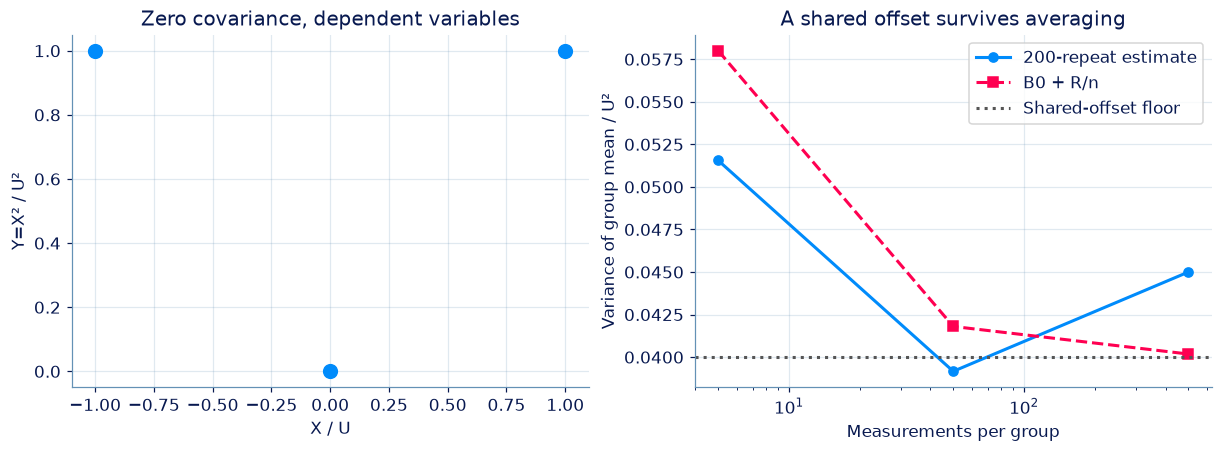

| n | 经验方差 / U² | 理论方差 / U² |
| --- | --- | --- |
| 5 | 0.0515509 | 0.058 |
| 50 | 0.039164 | 0.0418 |
| 500 | 0.0449959 | 0.04018 |

根种子 5202 ；每种 n 的重复数 200 ；PCG64；NumPy 2.5.3


In [4]:
sizes=[5,50,500];repeats=200;B0=.04;R=.09;root_seed=5202
streams=np.random.SeedSequence(root_seed).spawn(len(sizes)*repeats)
empirical=[]
for j,n in enumerate(sizes):
    errors=[]
    for b in range(repeats):
        rng=np.random.Generator(np.random.PCG64(streams[j*repeats+b]))
        offset=rng.normal(0,np.sqrt(B0))
        errors.append(offset+rng.normal(0,np.sqrt(R),n).mean())
    empirical.append(np.var(errors,ddof=1))
fig,axes=plt.subplots(1,2,figsize=(11,4))
axes[0].scatter(x,y,color=BLUE,s=80);axes[0].set(xlabel='X / U',ylabel='Y=X² / U²',title='Zero covariance, dependent variables')
axes[1].plot(sizes,empirical,'o-',color=BLUE,label='200-repeat estimate')
axes[1].plot(sizes,[B0+R/n for n in sizes],'s--',color=PINK,label='B0 + R/n')
axes[1].axhline(B0,color=GRAY,ls=':',label='Shared-offset floor')
axes[1].set(xscale='log',xlabel='Measurements per group',ylabel='Variance of group mean / U²',title='A shared offset survives averaging');axes[1].legend()
plt.show()
display(Markdown(show_table(['n','经验方差 / U²','理论方差 / U²'],zip(sizes,empirical,[B0+R/n for n in sizes]))))
print('根种子',root_seed,'；每种 n 的重复数',repeats,'；PCG64；NumPy',np.__version__)

## 结果解释

左图中 U 形关系非常明确，中心乘积平均却为零。右图大样本的组均值仍受共同偏移影响。每组里的读数共享 b；把所有点误当独立，会低估平均结果的不确定性。

### 独立核对

三点枚举给出精确反例；两个通道的和恒为 2，故其方差应为零。重复组均值使用高斯解析方差核对。

In [5]:
stats=paired_statistics([-1,0,1],[1,0,1])
assert math.isclose(stats[-1],0,abs_tol=1e-12)
vx,vy,cov=paired_statistics([0,1,2],[2,1,0])[2:]
assert math.isclose(vx+vy+2*cov,0,abs_tol=1e-12)
for n,v in zip(sizes,empirical):
    theory=B0+R/n
    assert abs(v-theory)<5*theory*np.sqrt(2/(repeats-1))
print('非线性依赖反例、和的方差及共享偏移的解析方差一致。')

非线性依赖反例、和的方差及共享偏移的解析方差一致。


[观察本章的动态可视化](http://127.0.0.1:8000/chapters/05-02-期望、方差、协方差与噪声/explore/)：改变一个条件，比较实现、分布与理论参照，再返回完整推导。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · Python 计算题：配对观察的协方差

同一时刻有两通道读数 xs、ys。求各通道均值、描述性方差（variance）和配对协方差（covariance），所有中心矩都使用分母 n。

**函数与代码模板**

```python
def solve(
    xs: list[float],
    ys: list[float],
) -> tuple[float, float, float, float, float]:
    # 依据题目规则计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `xs` | `list[float]` | 第一通道读数，按配对顺序。 | U |
| `ys` | `list[float]` | 第二通道读数，顺序不得打乱。 | U |

**返回值**

按以下顺序返回元组：(mean_x, mean_y, variance_x, variance_y, covariance)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `mean_x` | `float` | 第一通道均值。 | U |
| `mean_y` | `float` | 第二通道均值。 | U |
| `variance_x` | `float` | 第一通道中心平方均值。 | U² |
| `variance_y` | `float` | 第二通道中心平方均值。 | U² |
| `covariance` | `float` | 配对中心乘积均值。 | U² |

**计算规则**

均值分别计算；方差为 Σ(x−mean_x)²/n 等；协方差为 Σ(x−mean_x)(y−mean_y)/n。

**约束与边界**

- 所有数值有限；不修改输入（input）列表。
- 两个列表等长，长度 1—100；数值绝对值≤100。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| xs | 第一通道读数，按配对顺序。 | [0, 1, 2] | U |
| ys | 第二通道读数，顺序不得打乱。 | [2, 1, 0] | U |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
xs = [0, 1, 2]
ys = [2, 1, 0]

result = solve(xs, ys)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| mean_x | 第一通道均值。 | 1 | U |
| mean_y | 第二通道均值。 | 1 | U |
| variance_x | 第一通道中心平方均值。 | ≈ 0.6666667 | U² |
| variance_y | 第二通道中心平方均值。 | ≈ 0.6666667 | U² |
| covariance | 配对中心乘积均值。 | ≈ -0.6666667 | U² |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = (1.0,
                   1.0,
                   0.6666666666666666,
                   0.6666666666666666,
                   -0.6666666666666666)
```

**样例解释**

两均值均为 1，方差均为 2/3，协方差为 −2/3；反向变化给出负协方差。

允许 Python 标准库；绝对误差 1e-09 或相对误差 1e-08。

[作答：配对观察的协方差](http://127.0.0.1:8000/chapters/05-02-%E6%9C%9F%E6%9C%9B%E3%80%81%E6%96%B9%E5%B7%AE%E3%80%81%E5%8D%8F%E6%96%B9%E5%B7%AE%E4%B8%8E%E5%99%AA%E5%A3%B0/practice/?question=p05-covariance)

### 第 2 题 · 多项选择题：协方差为零是否独立

X 等概率（probability）取 −1、0、1，Y=X²。哪些成立？

- **A.** X 与 Y 独立。
- **B.** 知道 Y=0 就能确定 X=0。
- **C.** 零协方差（covariance）只排除这个中心乘积指标上的线性关联。
- **D.** Cov(X,Y)=0。

[作答：协方差为零是否独立](http://127.0.0.1:8000/chapters/05-02-%E6%9C%9F%E6%9C%9B%E3%80%81%E6%96%B9%E5%B7%AE%E3%80%81%E5%8D%8F%E6%96%B9%E5%B7%AE%E4%B8%8E%E5%99%AA%E5%A3%B0/practice/?question=p05-uncorrelated)

### 第 3 题 · 单项选择题：两个通道相加的波动

Var(X)=1，Var(Y)=4，Cov(X,Y)=1，单位均按相应平方量计。Var(X+Y) 是多少？

- **A.** 6。
- **B.** 3。
- **C.** 5。
- **D.** 7。

[作答：两个通道相加的波动](http://127.0.0.1:8000/chapters/05-02-%E6%9C%9F%E6%9C%9B%E3%80%81%E6%96%B9%E5%B7%AE%E3%80%81%E5%8D%8F%E6%96%B9%E5%B7%AE%E4%B8%8E%E5%99%AA%E5%A3%B0/practice/?question=p05-sum-variance)

### 第 4 题 · 单项选择题：恒定通道的相关系数

某通道所有读数相同，另一通道有变化。按标准相关系数（correlation coefficient） Cov(X,Y)/(sd(X)sd(Y))，正确做法是什么？

- **A.** 把零标准差（standard deviation）改为任意小数后解释为精确结果。
- **B.** 返回 1，因为两者来自同一实验。
- **C.** 返回 0 并宣称独立。
- **D.** 标记未定义，因为分母为零。

[作答：恒定通道的相关系数](http://127.0.0.1:8000/chapters/05-02-%E6%9C%9F%E6%9C%9B%E3%80%81%E6%96%B9%E5%B7%AE%E3%80%81%E5%8D%8F%E6%96%B9%E5%B7%AE%E4%B8%8E%E5%99%AA%E5%A3%B0/practice/?question=p05-correlation-zero-var)

### 第 5 题 · 单项选择题：多测几次能消除共同偏移吗

yᵢ=θ+b+vᵢ，b 在一组测量中固定，组间零均值、方差（variance） B；vᵢ 独立零均值、方差 R，且与 b 独立。n 次平均的误差方差为多少？

- **A.** (B+R)/n。
- **B.** B+R/n。
- **C.** B/n+R。
- **D.** 必为零。

[作答：多测几次能消除共同偏移吗](http://127.0.0.1:8000/chapters/05-02-%E6%9C%9F%E6%9C%9B%E3%80%81%E6%96%B9%E5%B7%AE%E3%80%81%E5%8D%8F%E6%96%B9%E5%B7%AE%E4%B8%8E%E5%99%AA%E5%A3%B0/practice/?question=p05-shared-offset)

**进一步阅读**

[MIT 6.041 讲义](https://ocw.mit.edu/courses/6-041-probabilistic-systems-analysis-and-applied-probability-fall-2010/pages/lecture-notes/)：第 10—11 讲：联合分布、协方差与条件期望。